# YOLO11-S + CBAM after SPPF — PyroNear SDIS Solo
**Architecture:** YOLO11-S with a single CBAM module injected after SPPF (Layer 10, 512 channels)  
**Dataset:** `pyronear/pyro-sdis` solo — nc=1 (smoke only)  
**Experiment:** Controlled ablation comparison vs. Vanilla YOLO11-S baseline  
**Reference:** Liu et al. 2024 (YOLOv8-CBAM: mAP@50=79.4%, Recall=72.7%)

---
**Comparison Baselines:**
- Vanilla YOLO11-S unified: recall=88.52%, FP=60.74%
- DCT+AG unified best: recall=92.05%, FP=58.49%
- Liu et al. 2024: mAP@50=79.4%, Recall=72.7%


## 1. Setup

In [1]:
!pip install ultralytics pycocotools datasets matplotlib opencv-python-headless -q

import os, gc, json, shutil, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from pathlib import Path
from PIL import Image

print(f"Torch       : {torch.__version__}")
print(f"CUDA        : {torch.cuda.is_available()}")
print(f"Device      : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print("Libraries loaded ✅")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 100.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26

## 2. PyroNear (pyro-sdis) — Load from HuggingFace & Convert to YOLO

**Source:** `pyronear/pyro-sdis` on HuggingFace (public, no token required)  
**Classes:** Smoke only (nc=1, class 0)  
**Directory:** `/kaggle/working/pyro_yolo` — identical to reference notebook


In [2]:
from datasets import load_dataset
from kaggle_secrets import UserSecretsClient

os.environ["HF_TOKEN"] = UserSecretsClient().get_secret("HF_TOKEN")

print("Loading PyroNear dataset...")
ds = load_dataset("pyronear/pyro-sdis")
print(f"Train samples : {len(ds['train'])}")
print(f"Val samples   : {len(ds['val'])}")

for split_name, split in [("Train", ds["train"]), ("Val", ds["val"])]:
    has_smoke = sum(1 for s in split if s["annotations"] and s["annotations"].strip())
    no_smoke  = len(split) - has_smoke
    print(f"\n{split_name}:")
    print(f"  Smoke positives  : {has_smoke}")
    print(f"  Hard negatives   : {no_smoke} ({no_smoke/len(split):.1%})")


Loading PyroNear dataset...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00006.parquet:   0%|          | 0.00/481M [00:00<?, ?B/s]

data/train-00001-of-00006.parquet:   0%|          | 0.00/485M [00:00<?, ?B/s]

data/train-00002-of-00006.parquet:   0%|          | 0.00/482M [00:00<?, ?B/s]

...

data/train-00005-of-00006.parquet:   0%|          | 0.00/483M [00:00<?, ?B/s]

data/val-00000-of-00001.parquet:   0%|          | 0.00/390M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/29537 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/4099 [00:00<?, ? examples/s]

Train samples : 29537
Val samples   : 4099

Train:
  Smoke positives  : 24792
  Hard negatives   : 4745 (16.1%)

Val:
  Smoke positives  : 3345
  Hard negatives   : 754 (18.4%)


In [3]:
# ── Directory structure identical to reference notebook ───────────────────────
PYRO_DIRS = {
    "train_imgs": "/kaggle/working/pyro_yolo/images/train",
    "val_imgs":   "/kaggle/working/pyro_yolo/images/val",
    "train_lbls": "/kaggle/working/pyro_yolo/labels/train",
    "val_lbls":   "/kaggle/working/pyro_yolo/labels/val",
}
for d in PYRO_DIRS.values():
    os.makedirs(d, exist_ok=True)


def save_pyro_split(split, img_dir, lbl_dir, split_name):
    """Identical conversion function from reference notebook."""
    for i, sample in enumerate(split):
        img_name = Path(sample["image_name"]).stem
        sample["image"].save(str(Path(img_dir) / f"{img_name}.jpg"))
        ann = sample["annotations"]
        with open(Path(lbl_dir) / f"{img_name}.txt", "w") as f:
            if ann and ann.strip():
                lines = []
                for line in ann.strip().split("\n"):
                    parts = line.strip().split()
                    if len(parts) == 5:
                        _, cx, cy, bw, bh = parts
                        lines.append(f"0 {cx} {cy} {bw} {bh}")
                f.write("\n".join(lines))
        if (i + 1) % 5000 == 0:
            print(f"  {split_name}: {i+1} saved...")
    print(f"  {split_name} done: {len(split)} images")


print("Converting PyroNear train...")
save_pyro_split(ds["train"], PYRO_DIRS["train_imgs"], PYRO_DIRS["train_lbls"], "train")
print("Converting PyroNear val...")
save_pyro_split(ds["val"], PYRO_DIRS["val_imgs"], PYRO_DIRS["val_lbls"], "val")

# Free HF dataset from memory
del ds
gc.collect()


Converting PyroNear train...
  train: 5000 saved...
  train: 10000 saved...
  train: 15000 saved...
  train: 20000 saved...
  train: 25000 saved...
  train done: 29537 images
Converting PyroNear val...
  val done: 4099 images


224

In [4]:
print("── PyroNear Solo Dataset Summary ─────────────────────────────")
n_val_total = n_val_positive = n_val_hardneg = 0

for split in ["train", "val"]:
    img_dir = Path(f"/kaggle/working/pyro_yolo/images/{split}")
    lbl_dir = Path(f"/kaggle/working/pyro_yolo/labels/{split}")
    imgs = list(img_dir.glob("*.jpg"))
    lbls = list(lbl_dir.glob("*.txt"))
    pos  = sum(1 for l in lbls if l.read_text().strip())
    neg  = len(lbls) - pos
    print(f"  {split:5s}: {len(imgs):6d} images | {pos:6d} positive | {neg:5d} hard negative ({neg/max(len(lbls),1):.1%})")
    if split == "val":
        n_val_total    = len(imgs)
        n_val_positive = pos
        n_val_hardneg  = neg

print(f"\n  n_val_total    = {n_val_total}")
print(f"  n_val_positive = {n_val_positive}")
print(f"  n_val_hardneg  = {n_val_hardneg}")


── PyroNear Solo Dataset Summary ─────────────────────────────
  train:  29537 images |  24792 positive |  4745 hard negative (16.1%)
  val  :   4099 images |   3345 positive |   754 hard negative (18.4%)

  n_val_total    = 4099
  n_val_positive = 3345
  n_val_hardneg  = 754


## 3. Data YAML — PyroNear Solo (nc=1)

In [5]:
# ── Solo YAML: nc=1, smoke only — at /kaggle/working/pyro_solo.yaml ──────────
pyro_solo_yaml = """# PyroNear pyro-sdis solo dataset
# Source: pyronear/pyro-sdis (HuggingFace, Apache 2.0)
# nc=1: smoke only

path: /kaggle/working/pyro_yolo
train: images/train
val:   images/val

nc: 1
names:
  0: smoke
"""

with open("/kaggle/working/pyro_solo.yaml", "w") as f:
    f.write(pyro_solo_yaml.strip())
print(pyro_solo_yaml)
print("pyro_solo.yaml written ✅")


# PyroNear pyro-sdis solo dataset
# Source: pyronear/pyro-sdis (HuggingFace, Apache 2.0)
# nc=1: smoke only

path: /kaggle/working/pyro_yolo
train: images/train
val:   images/val

nc: 1
names:
  0: smoke

pyro_solo.yaml written ✅


## 4. CBAM Module Definition

**Reference:** Woo et al., ECCV 2018 — https://arxiv.org/abs/1807.06521  
**Insertion point:** Layer 10 — immediately after SPPF (512 channels)  
**Note:** This is the SPPF position (not C2PSA as in the ablation notebook). In YOLO11-S,  
SPPF is at layer 9 (pre-scale) → after depth scaling at s=0.50 it remains at index 9,  
but CBAM registers as layer 10 in the custom YAML.  
**Parameter cost:** ~8,224 additional params at 512 channels (negligible vs 9.4M baseline)


In [6]:
# ── Copied verbatim from the ablation notebook (CBAM module definition) ────────

class ChannelAttention(nn.Module):
    """Channel attention: shared MLP over avg-pooled and max-pooled descriptors."""
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Conv2d(channels, channels // reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // reduction, channels, 1, bias=False),
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return x * self.sigmoid(self.mlp(self.avg_pool(x)) + self.mlp(self.max_pool(x)))


class SpatialAttention(nn.Module):
    """Spatial attention: 2D map from channel-wise avg and max projections."""
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv    = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        return x * self.sigmoid(self.conv(torch.cat([avg_out, max_out], dim=1)))


class CBAM(nn.Module):
    """
    Full CBAM: channel attention → spatial attention (paper-prescribed order).
    Inserted at layer 10 of YOLO11-S immediately after SPPF (512 channels).
    """
    def __init__(self, channels, reduction=16, kernel_size=7):
        super().__init__()
        self.ca = ChannelAttention(channels, reduction)
        self.sa = SpatialAttention(kernel_size)

    def forward(self, x):
        return self.sa(self.ca(x))


# ── Sanity check ──────────────────────────────────────────────────────────────
_x    = torch.randn(2, 512, 20, 20)
_cbam = CBAM(channels=512)
_out  = _cbam(_x)
assert _out.shape == _x.shape, "Shape mismatch!"
print(f"Input  : {_x.shape}")
print(f"Output : {_out.shape}  ✅")
print(f"Params : {sum(p.numel() for p in _cbam.parameters()):,}")


Input  : torch.Size([2, 512, 20, 20])
Output : torch.Size([2, 512, 20, 20])  ✅
Params : 32,866


## 5. Register CBAM into Ultralytics Runtime

In [7]:
# ── Identical registration pattern from the ablation notebook ─────────────────
import ultralytics.nn.modules as ulm
import ultralytics.nn.modules.conv as conv_mod
import ultralytics.nn.tasks as tasks_mod

# 1. Inject into module namespaces
for mod in [conv_mod, ulm, tasks_mod]:
    mod.CBAM             = CBAM
    mod.ChannelAttention = ChannelAttention
    mod.SpatialAttention = SpatialAttention

# 2. Patch parse_model module_map dict (ultralytics >= 8.x)
patched = False
for attr_name in dir(tasks_mod):
    obj = getattr(tasks_mod, attr_name, None)
    if isinstance(obj, dict) and 'C2PSA' in str(obj):
        obj['CBAM']             = CBAM
        obj['ChannelAttention'] = ChannelAttention
        obj['SpatialAttention'] = SpatialAttention
        print(f"Patched CBAM into tasks_mod.{attr_name} ✅")
        patched = True
        break

if not patched:
    print("module_map not found via dict scan — globals() fallback applied ✅")
print("Ultralytics runtime registration complete ✅")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
module_map not found via dict scan — globals() fallback applied ✅
Ultralytics runtime registration complete ✅


## 6. CBAM YAML — Modified YOLO11-S Architecture

CBAM inserted at **layer 10**, immediately after SPPF (layer 9, 512 channels).  
In YOLO11-S the backbone ends with SPPF→C2PSA. We inject CBAM *between* SPPF and C2PSA,  
so C2PSA receives the CBAM-attended feature map.  
All subsequent layer indices shift by +1.


In [8]:
cbam_sppf_yaml_str = """
# YOLO11-S + CBAM after SPPF
# CBAM: Woo et al., ECCV 2018 (https://arxiv.org/abs/1807.06521)
# Insertion: Layer 10 after SPPF (layer 9, 512 channels)
# Phase: CBAM_SPPF_pyro_solo

nc: 1  # smoke only

scales:
  s: [0.50, 0.50, 1024]

backbone:
  - [-1, 1, Conv,  [64, 3, 2]]           # 0  P1/2
  - [-1, 1, Conv,  [128, 3, 2]]          # 1  P2/4
  - [-1, 2, C3k2,  [256, False, 0.25]]   # 2
  - [-1, 1, Conv,  [256, 3, 2]]          # 3  P3/8
  - [-1, 2, C3k2,  [512, False, 0.25]]   # 4
  - [-1, 1, Conv,  [512, 3, 2]]          # 5  P4/16
  - [-1, 2, C3k2,  [512, True]]          # 6
  - [-1, 1, Conv,  [1024, 3, 2]]         # 7  P5/32
  - [-1, 2, C3k2,  [1024, True]]         # 8
  - [-1, 1, SPPF,  [1024, 5]]            # 9  SPPF (512 out after scale)
  - [-1, 1, CBAM,  [512]]               # 10 CBAM channel+spatial after SPPF (512ch)
  - [-1, 2, C2PSA, [1024]]              # 11 C2PSA built-in spatial attention

head:
  - [-1,       1, nn.Upsample, [None, 2, nearest]]  # 12
  - [[-1, 6],  1, Concat,      [1]]                 # 13 cat P4 (layer 6)
  - [-1,       2, C3k2,        [512, False]]         # 14

  - [-1,       1, nn.Upsample, [None, 2, nearest]]  # 15
  - [[-1, 4],  1, Concat,      [1]]                 # 16 cat P3 (layer 4)
  - [-1,       2, C3k2,        [256, False]]         # 17 P3/8  detect

  - [-1,       1, Conv,        [256, 3, 2]]          # 18
  - [[-1, 14], 1, Concat,      [1]]                 # 19 cat P4 (layer 14)
  - [-1,       2, C3k2,        [512, False]]         # 20 P4/16 detect

  - [-1,       1, Conv,        [512, 3, 2]]          # 21
  - [[-1, 11], 1, Concat,      [1]]                 # 22 cat C2PSA (layer 11)
  - [-1,       2, C3k2,        [1024, True]]         # 23 P5/32 detect

  - [[17, 20, 23], 1, Detect, [nc]]                 # 24
"""

with open("/kaggle/working/yolo11s_cbam_sppf.yaml", "w") as f:
    f.write(cbam_sppf_yaml_str.strip())
print("yolo11s_cbam_sppf.yaml written ✅")


yolo11s_cbam_sppf.yaml written ✅


## 7. Architecture Verification (ALL checks must pass)

In [9]:
from ultralytics import YOLO

print("── Step 1: Build model from YAML ────────────────────────────────")
test_model = YOLO("/kaggle/working/yolo11s_cbam_sppf.yaml")

print("\n── Step 2: Layer index verification ──────────────────────────────")
print("Layer index | Type")
print("-" * 40)
for i, layer in enumerate(test_model.model.model):
    marker = " ← CBAM ✅" if type(layer).__name__ == 'CBAM' else ""
    print(f"  [{i:2d}]  {type(layer).__name__}{marker}")

cbam_layer = test_model.model.model[10]
assert type(cbam_layer).__name__ == 'CBAM', (
    f"FAIL: Layer 10 is {type(cbam_layer).__name__}, expected CBAM")
print("\n✅ CHECK 1 PASSED: Layer 10 is CBAM")

print("\n── Step 3: Channel verification ──────────────────────────────────")
# CBAM at 512 channels: ChannelAttention MLP input = 512
cbam_ca_in = cbam_layer.ca.mlp[0].in_channels
assert cbam_ca_in == 512, f"FAIL: CBAM input channels = {cbam_ca_in}, expected 512"
print(f"✅ CHECK 2 PASSED: CBAM input channels = {cbam_ca_in}")

print("\n── Step 4: Forward pass shape check (nc=1, imgsz=640, batch=2) ──")
test_model.model.eval()
with torch.no_grad():
    dummy = torch.zeros(2, 3, 640, 640)
    out   = test_model.model(dummy)
    # out is a tuple; first element is the detection tensor
    pred  = out[0] if isinstance(out, (tuple, list)) else out
print(f"  Output shape: {pred.shape}")
assert pred.shape == (2, 5, 8400), (
    f"FAIL: expected (2, 5, 8400), got {pred.shape}")
print("✅ CHECK 3 PASSED: Forward pass shape = (2, 5, 8400)")

print("\n── Step 5: Parameter count ────────────────────────────────────────")
_arch_params_M = sum(p.numel() for p in test_model.model.parameters()) / 1e6
_cbam_params   = sum(p.numel() for p in cbam_layer.parameters())
print(f"  Total parameters : {_arch_params_M:.4f}M")
print(f"  CBAM parameters  : {_cbam_params:,}")
assert 9.3 < _arch_params_M < 9.6, (
    f"FAIL: parameter count {_arch_params_M:.4f}M outside expected range [9.3M, 9.6M]")
print(f"✅ CHECK 4 PASSED: ~{_arch_params_M:.4f}M parameters (expected ~9.45M)")
# Note: params_M for results JSON is set from eval_model in the evaluation section

print("\n" + "="*55)
print("  ALL ARCHITECTURE CHECKS PASSED — safe to train ✅")
print("="*55)

del test_model
gc.collect()
torch.cuda.empty_cache()


── Step 1: Build model from YAML ────────────────────────────────

── Step 2: Layer index verification ──────────────────────────────
Layer index | Type
----------------------------------------
  [ 0]  Conv
  [ 1]  Conv
  [ 2]  C3k2
  [ 3]  Conv
  [ 4]  C3k2
  [ 5]  Conv
  [ 6]  C3k2
  [ 7]  Conv
  [ 8]  C3k2
  [ 9]  SPPF
  [10]  CBAM ← CBAM ✅
  [11]  C2PSA
  [12]  Upsample
  [13]  Concat
  [14]  C3k2
  [15]  Upsample
  [16]  Concat
  [17]  C3k2
  [18]  Conv
  [19]  Concat
  [20]  C3k2
  [21]  Conv
  [22]  Concat
  [23]  C3k2
  [24]  Detect

✅ CHECK 1 PASSED: Layer 10 is CBAM

── Step 3: Channel verification ──────────────────────────────────
✅ CHECK 2 PASSED: CBAM input channels = 512

── Step 4: Forward pass shape check (nc=1, imgsz=640, batch=2) ──
  Output shape: torch.Size([2, 5, 8400])
✅ CHECK 3 PASSED: Forward pass shape = (2, 5, 8400)

── Step 5: Parameter count ────────────────────────────────────────
  Total parameters : 9.4610M
  CBAM parameters  : 32,866
✅ CHECK 4 PASSED: ~

## 8. Cold-Start Model Preparation

Cold-start from COCO pretrained `yolo11s.pt` weights, transferred into the CBAM architecture.  
The new CBAM layer (layer 10) initialises randomly; all other layers warm-start from COCO.


In [10]:
print("Building YOLO11-S + CBAM (SPPF) and transferring COCO weights...")

# 1. Build the fresh skeleton from custom YAML
cbam_model = YOLO("/kaggle/working/yolo11s_cbam_sppf.yaml")

# 2. Load standard YOLO11-S COCO pretrained weights as donor
base_model       = YOLO("yolo11s.pt")
base_state_dict  = base_model.model.state_dict()
cbam_state_dict  = cbam_model.model.state_dict()

# 3. Transfer weights: layers 0-9 stay at same index; layers 10+ shift by +1
#    (CBAM is inserted at index 10, pushing C2PSA from 10→11, head from 11→12...)
transferred = 0
for k, v in base_state_dict.items():
    parts = k.split('.')
    if len(parts) > 1 and parts[1].isdigit():
        layer_idx = int(parts[1])
        if layer_idx < 10:
            new_key = k                      # backbone layers 0-9: unchanged
        else:
            parts[1] = str(layer_idx + 1)   # layers 10+ shift +1 for CBAM
            new_key = '.'.join(parts)
        if new_key in cbam_state_dict and cbam_state_dict[new_key].shape == v.shape:
            cbam_state_dict[new_key] = v
            transferred += 1

cbam_model.model.load_state_dict(cbam_state_dict, strict=False)
print(f"  Transferred {transferred} weight tensors from COCO yolo11s.pt")
print(f"  CBAM layer (layer 10) → randomly initialised")
print(f"  Backbone layers 0-9  → COCO pretrained")
print(f"  Head layers 11-24    → COCO pretrained (index-shifted)")

cbam_model.save("/kaggle/working/cbam_sppf_coco_init.pt")
print("  Saved initialised model → cbam_sppf_coco_init.pt ✅")

del base_model, base_state_dict, cbam_state_dict
gc.collect()
torch.cuda.empty_cache()


Building YOLO11-S + CBAM (SPPF) and transferring COCO weights...
  Transferred 493 weight tensors from COCO yolo11s.pt
  CBAM layer (layer 10) → randomly initialised
  Backbone layers 0-9  → COCO pretrained
  Head layers 11-24    → COCO pretrained (index-shifted)
  Saved initialised model → cbam_sppf_coco_init.pt ✅


## 9. Train YOLO11-S + CBAM (after SPPF) — PyroNear Solo

In [11]:
cbam_model = YOLO("/kaggle/working/cbam_sppf_coco_init.pt")

t_start = time.time()

results_cbam = cbam_model.train(
    data      = "/kaggle/working/pyro_solo.yaml",
    epochs    = 50,
    batch     = 16,
    imgsz     = 640,
    lr0       = 0.01,
    lrf       = 0.01,
    optimizer = "auto",
    patience  = 15,
    cls_pw    = 0.0,
    seed      = 0,
    workers   = 2,
    device    = 0,
    project   = "/kaggle/working/runs",
    name      = "yolo11s_cbam_sppf_pyro",
    save      = True,
    plots     = True,
    exist_ok  = True,
)

train_seconds = time.time() - t_start

# Robust epoch count: read results.csv written by Ultralytics (always accurate,
# correctly reflects early stopping — avoids fragile results_cbam.epoch attribute)
_results_csv = "/kaggle/working/runs/yolo11s_cbam_sppf_pyro/results.csv"
try:
    _df_tmp = pd.read_csv(_results_csv)
    epochs_actual = int(len(_df_tmp))
except Exception:
    # Final fallback: parse from trainer if CSV not yet flushed
    epochs_actual = int(getattr(results_cbam, 'epoch', 49)) + 1

print(f"\nTraining complete in {train_seconds/60:.1f} min ({train_seconds:.0f}s)")
print(f"Epochs run: {epochs_actual}")

shutil.make_archive("/kaggle/working/yolo11s_cbam_sppf_pyro_results", "zip",
                    "/kaggle/working/runs/yolo11s_cbam_sppf_pyro")
print("Run directory zipped ✅")


Ultralytics 8.4.57 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/pyro_solo.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/working/cbam_sppf_coco_init.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11s_cbam_sppf_pyro, nbs=64, nms=False, opset=None, optimize=False, optimi

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/50      4.12G      1.747      2.035       1.08          1        640: 100% ━━━━━━━━━━━━ 1847/1847 2.4it/s 12:38
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 129/129 4.5it/s 28.6s
                   all       4099       3942      0.487      0.477      0.429      0.209

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/50      4.14G       1.78      1.467      1.079          1        640: 100% ━━━━━━━━━━━━ 1847/1847 2.9it/s 10:37
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 129/129 5.8it/s 22.2s
                   all       4099       3942      0.578      0.546      0.532       0.25

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/50      4.14G      2.086      1.481      1.042         16        640: 0% ──────────── 0/1847  0.3s

...

      48/50      4.14G      1.028     0.6591     0.8948          1        640: 100% ━━━━━━━━━━━━ 1847/1847 3.2it/s 9:39
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 129/129 5.7it/s 22.7s
                   all       4099       3942      0.738      0.714      0.754      0.482

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      49/50      4.14G     0.8867      0.476     0.9245         16        640: 0% ──────────── 0/1847  0.3s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      49/50      4.14G       1.02     0.6468     0.8915          1        640: 100% ━━━━━━━━━━━━ 1847/1847 3.2it/s 9:39
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 129/129 5.9it/s 21.8s
                   all       4099       3942      0.737      0.715      0.752      0.482

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      50/50      4.14G       1.06     0.6952     0.7553         16        640: 0% ──────────── 0/1847  0.3s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      50/50      4.14G      1.012     0.6401     0.8894          1        640: 100% ━━━━━━━━━━━━ 1847/1847 3.2it/s 9:39
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 129/129 5.6it/s 22.8s
                   all       4099       3942      0.739      0.715      0.752      0.482

50 epochs completed in 8.461 hours.
Optimizer stripped from /kaggle/working/runs/yolo11s_cbam_sppf_pyro/weights/last.pt, 19.2MB
Optimizer stripped from /kaggle/working/runs/yolo11s_cbam_sppf_pyro/weights/best.pt, 19.2MB

Validating /kaggle/working/runs/yolo11s_cbam_sppf_pyro/weights/best.pt...
Ultralytics 8.4.57 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s_cbam_sppf summary (fused): 109 layers, 9,446,053 parameters, 0 gradients, 21.4 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 129/129 5.5it/s 23.7s
                   all       4099       3942      0.738   

## 10. Training Curves

── Per-epoch summary ──────────────────────────────────────────
 epoch  train/box_loss  val/box_loss  metrics/mAP50(B)  metrics/precision(B)  metrics/recall(B)
     1         1.74650       1.81297           0.42867               0.48690            0.47717
     2         1.77965       1.81157           0.53157               0.57810            0.54642
     3         1.85126       1.79347           0.48708               0.53136            0.53614
     4         1.79850       1.68214           0.56146               0.60100            0.57774
     5         1.68353       1.57613           0.60779               0.61855            0.63554
     6         1.59781       1.49528           0.63580               0.62133            0.65016
     7         1.55734       1.44652           0.64495               0.64802            0.65398
     8         1.51106       1.46871           0.63197               0.64107            0.63749
     9         1.48167       1.38813           0.67402               0.6

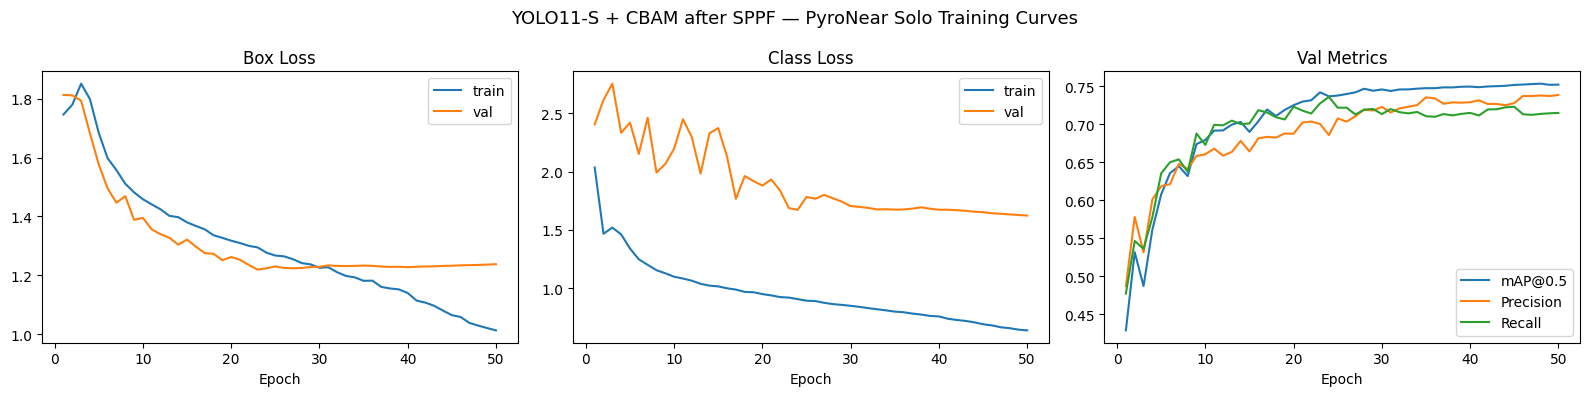

Training curves saved ✅


In [12]:
CBAM_DIR = "/kaggle/working/runs/yolo11s_cbam_sppf_pyro"
BEST_PT  = f"{CBAM_DIR}/weights/best.pt"

df = pd.read_csv(f"{CBAM_DIR}/results.csv")
df.columns = df.columns.str.strip()

print("── Per-epoch summary ──────────────────────────────────────────")
cols = ["epoch", "train/box_loss", "val/box_loss",
        "metrics/mAP50(B)", "metrics/precision(B)", "metrics/recall(B)"]
available = [c for c in cols if c in df.columns]
print(df[available].to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("YOLO11-S + CBAM after SPPF — PyroNear Solo Training Curves", fontsize=13)

axes[0].plot(df["epoch"], df["train/box_loss"], label="train")
axes[0].plot(df["epoch"], df["val/box_loss"],   label="val")
axes[0].set_title("Box Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

if "train/cls_loss" in df.columns:
    axes[1].plot(df["epoch"], df["train/cls_loss"], label="train")
    axes[1].plot(df["epoch"], df["val/cls_loss"],   label="val")
axes[1].set_title("Class Loss"); axes[1].set_xlabel("Epoch"); axes[1].legend()

if "metrics/mAP50(B)" in df.columns:
    axes[2].plot(df["epoch"], df["metrics/mAP50(B)"],     label="mAP@0.5")
if "metrics/precision(B)" in df.columns:
    axes[2].plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
if "metrics/recall(B)" in df.columns:
    axes[2].plot(df["epoch"], df["metrics/recall(B)"],    label="Recall")
axes[2].set_title("Val Metrics"); axes[2].set_xlabel("Epoch"); axes[2].legend()

plt.tight_layout()
plt.savefig("/kaggle/working/cbam_sppf_training_curves.png", dpi=120)
plt.show()
print("Training curves saved ✅")


## 11. Evaluation

### 11a. Box-Level Evaluation via model.val()

In [13]:
# ── Memory reset ──────────────────────────────────────────────────────────────
try:
    del cbam_model
except NameError:
    pass
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()
print(f"VRAM free: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB ✅")

eval_model = YOLO(BEST_PT)

metrics = eval_model.val(
    data     = "/kaggle/working/pyro_solo.yaml",
    split    = "val",
    imgsz    = 640,
    batch    = 8,
    device   = 0,
    plots    = True,
    project  = CBAM_DIR,
    name     = "eval_box",
    exist_ok = True,
)

precision_box = float(metrics.box.mp)
recall_box    = float(metrics.box.mr)
map50         = float(metrics.box.map50)
map5095       = float(metrics.box.map)
f1_box        = 2 * precision_box * recall_box / (precision_box + recall_box + 1e-9)
params_M      = sum(p.numel() for p in eval_model.model.parameters()) / 1e6

print(f"\n── Box-level metrics (model.val()) ──────────────────────────")
print(f"  mAP@0.5      : {map50:.4f}")
print(f"  mAP@0.5:0.95 : {map5095:.4f}")
print(f"  Precision    : {precision_box:.4f}")
print(f"  Recall       : {recall_box:.4f}")
print(f"  F1           : {f1_box:.4f}")
print(f"  Params       : {params_M:.4f}M")


VRAM free: 15.4 GB ✅
Ultralytics 8.4.57 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s_cbam_sppf summary (fused): 109 layers, 9,446,053 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1569.6±504.7 MB/s, size: 73.4 KB)
val: Scanning /kaggle/working/pyro_yolo/labels/val.cache... 4099 images, 754 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4099/4099 1.1Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 513/513 14.1it/s 36.4s
                   all       4099       3942      0.739      0.713      0.754      0.484
Speed: 0.5ms preprocess, 5.0ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /kaggle/working/runs/yolo11s_cbam_sppf_pyro/eval_box

── Box-level metrics (model.val()) ──────────────────────────
  mAP@0.5      : 0.7544
  mAP@0.5:0.95 : 0.4838
  Precision    : 0.7389
  Recall       : 0.7128
  F1           : 0.7256
  Params       : 9.4

### 11b. Image-Level Evaluation — Single Low-Conf Prediction Pass

In [14]:
# ── Single low-conf pass (conf=0.001) — store max confidence per image ────────
img_val_dir = Path("/kaggle/working/pyro_yolo/images/val")
lbl_val_dir = Path("/kaggle/working/pyro_yolo/labels/val")

val_images  = sorted(img_val_dir.glob("*.jpg"))
val_labels  = [lbl_val_dir / f"{p.stem}.txt" for p in val_images]

print(f"Running single low-conf inference on {len(val_images)} val images...")
print("(conf=0.001 — one pass, store max conf per image)")

BATCH_SIZE = 64
max_confs  = []   # max detection confidence per image (0.0 if no detections)
gt_flags   = []   # True if image has smoke annotation

for start in range(0, len(val_images), BATCH_SIZE):
    batch_imgs = [str(p) for p in val_images[start:start+BATCH_SIZE]]
    batch_lbls = val_labels[start:start+BATCH_SIZE]
    preds = eval_model.predict(
        source=batch_imgs, imgsz=640, conf=0.001,
        device=0, verbose=False
    )
    for pred, lbl_path in zip(preds, batch_lbls):
        has_gt = lbl_path.exists() and lbl_path.read_text().strip() != ""
        gt_flags.append(has_gt)
        if len(pred.boxes) > 0:
            max_confs.append(float(pred.boxes.conf.max().cpu()))
        else:
            max_confs.append(0.0)
    torch.cuda.empty_cache()

max_confs = np.array(max_confs)
gt_flags  = np.array(gt_flags)

n_pos = gt_flags.sum()
n_neg = (~gt_flags).sum()
print(f"\nVal set: {len(val_images)} images | {n_pos} positive | {n_neg} hard negative")
print(f"Max conf range: [{max_confs.min():.4f}, {max_confs.max():.4f}]")


Running single low-conf inference on 4099 val images...
(conf=0.001 — one pass, store max conf per image)

Val set: 4099 images | 3345 positive | 754 hard negative
Max conf range: [0.0000, 0.8972]


### 11c. Confidence Threshold Sweep — τ ∈ {0.10, 0.15, 0.25, 0.35, 0.50}

In [15]:
# ── Analytical sweep over stored max_confs ────────────────────────────────────
sweep_taus = [0.10, 0.15, 0.25, 0.35, 0.50]
sweep      = {}

print(f"\n{'τ':>6} {'Recall':>8} {'FP Rate':>8} {'Precision':>10} {'F1':>8}")
print("-" * 46)

for tau in sweep_taus:
    detected = max_confs >= tau
    tp = int(( detected &  gt_flags).sum())
    fp = int(( detected & ~gt_flags).sum())
    fn = int((~detected &  gt_flags).sum())
    tn = int((~detected & ~gt_flags).sum())

    recall    = tp / (tp + fn + 1e-9)
    fp_rate   = fp / (fp + tn + 1e-9)
    precision = tp / (tp + fp + 1e-9)
    f1        = 2 * precision * recall / (precision + recall + 1e-9)

    sweep[str(tau)] = {
        "tau": tau, "tp": tp, "fp": fp, "fn": fn, "tn": tn,
        "recall": round(recall, 4), "fp_rate": round(fp_rate, 4),
        "precision": round(precision, 4), "f1": round(f1, 4),
    }
    print(f"  {tau:.2f}  {recall:>8.4f} {fp_rate:>8.4f} {precision:>10.4f} {f1:>8.4f}")

# ── Primary operating point at τ=0.25 ────────────────────────────────────────
op = sweep["0.25"]
img_recall  = op["recall"]
img_fp_rate = op["fp_rate"]
f1_025      = op["f1"]
precision_img = op["precision"]

print(f"\n── Primary operating point τ=0.25 ───────────────────────────")
print(f"  Image-level Recall    : {img_recall:.4f}  ({img_recall*100:.2f}%)")
print(f"  Image-level FP Rate   : {img_fp_rate:.4f}  ({img_fp_rate*100:.2f}%)")
print(f"  Image-level Precision : {precision_img:.4f}  ({precision_img*100:.2f}%)")
print(f"  Image-level F1        : {f1_025:.4f}")



     τ   Recall  FP Rate  Precision       F1
----------------------------------------------
  0.10    0.9477   0.6751     0.8616   0.9026
  0.15    0.9303   0.6180     0.8698   0.8990
  0.25    0.8891   0.5411     0.8794   0.8842
  0.35    0.8257   0.4310     0.8947   0.8588
  0.50    0.6951   0.2812     0.9164   0.7905

── Primary operating point τ=0.25 ───────────────────────────
  Image-level Recall    : 0.8891  (88.91%)
  Image-level FP Rate   : 0.5411  (54.11%)
  Image-level Precision : 0.8794  (87.94%)
  Image-level F1        : 0.8842


In [16]:
# ── Optimal F1 search over τ ∈ [0.01, 0.99] step 0.01 ───────────────────────
best_f1 = 0.0
tau_optimal = 0.25

for tau_fine in np.arange(0.01, 1.00, 0.01):
    detected = max_confs >= tau_fine
    tp_ = int(( detected &  gt_flags).sum())
    fp_ = int(( detected & ~gt_flags).sum())
    fn_ = int((~detected &  gt_flags).sum())
    prec_ = tp_ / (tp_ + fp_ + 1e-9)
    rec_  = tp_ / (tp_ + fn_ + 1e-9)
    f1_   = 2 * prec_ * rec_ / (prec_ + rec_ + 1e-9)
    if f1_ > best_f1:
        best_f1     = f1_
        tau_optimal = round(float(tau_fine), 2)

f1_optimal = round(best_f1, 4)
print(f"Optimal F1 search result:")
print(f"  τ_optimal  : {tau_optimal:.2f}")
print(f"  F1_optimal : {f1_optimal:.4f}")


Optimal F1 search result:
  τ_optimal  : 0.01
  F1_optimal : 0.9077


### 11d. Threshold Sweep ROC-Style Plot

TypeError: only 0-dimensional arrays can be converted to Python scalars

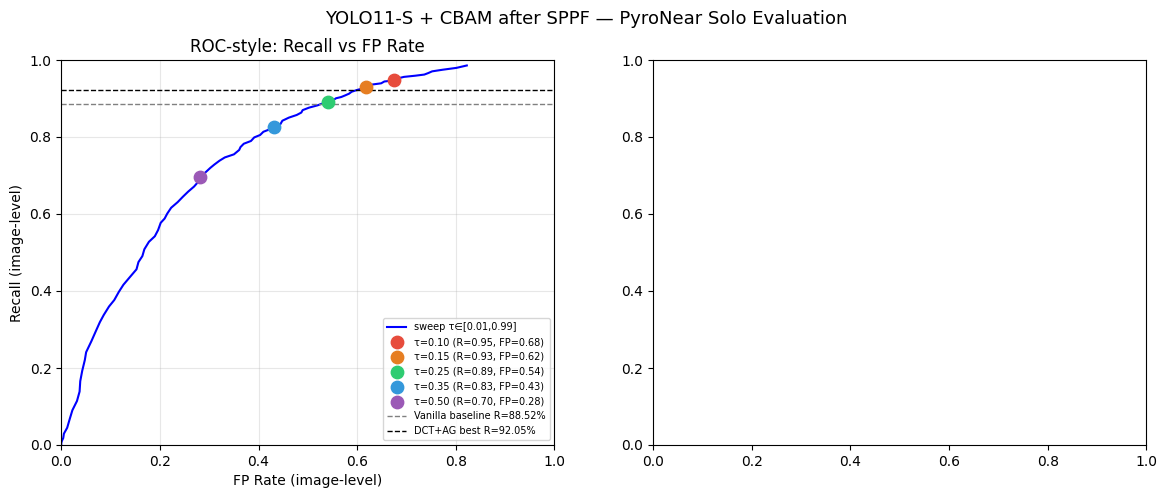

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("YOLO11-S + CBAM after SPPF — PyroNear Solo Evaluation", fontsize=13)

# ── Left: ROC-style (FP Rate vs Recall) ──────────────────────────────────────
taus_fine = np.arange(0.01, 1.00, 0.01)
recalls_fine   = []
fp_rates_fine  = []

for tau_f in taus_fine:
    detected = max_confs >= tau_f
    tp_ = int(( detected &  gt_flags).sum())
    fp_ = int(( detected & ~gt_flags).sum())
    fn_ = int((~detected &  gt_flags).sum())
    tn_ = int((~detected & ~gt_flags).sum())
    recalls_fine.append(tp_ / (tp_ + fn_ + 1e-9))
    fp_rates_fine.append(fp_ / (fp_ + tn_ + 1e-9))

axes[0].plot(fp_rates_fine, recalls_fine, 'b-', linewidth=1.5, label="sweep τ∈[0.01,0.99]")

# Highlight named taus
colors = ['#e74c3c','#e67e22','#2ecc71','#3498db','#9b59b6']
for tau_s, col in zip(sweep_taus, colors):
    s = sweep[str(tau_s)]
    axes[0].scatter(s["fp_rate"], s["recall"], s=80, color=col, zorder=5,
                    label=f"τ={tau_s:.2f} (R={s['recall']:.2f}, FP={s['fp_rate']:.2f})")

# Baseline references
axes[0].axhline(0.8852, color='gray',  ls='--', lw=1, label="Vanilla baseline R=88.52%")
axes[0].axhline(0.9205, color='black', ls='--', lw=1, label="DCT+AG best R=92.05%")

axes[0].set_xlabel("FP Rate (image-level)")
axes[0].set_ylabel("Recall (image-level)")
axes[0].set_title("ROC-style: Recall vs FP Rate")
axes[0].legend(fontsize=7, loc="lower right")
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3)

# ── Right: F1 vs τ ───────────────────────────────────────────────────────────
f1s_fine = [
    2*(p*r)/(p+r+1e-9)
    for p, r in zip(
        [int((max_confs>=t)&gt_flags).sum()/max(int((max_confs>=t).sum()),1)
         for t in taus_fine],
        recalls_fine
    )
]
# recompute properly
f1s_fine = []
for tau_f in taus_fine:
    detected = max_confs >= tau_f
    tp_ = int(( detected &  gt_flags).sum())
    fp_ = int(( detected & ~gt_flags).sum())
    fn_ = int((~detected &  gt_flags).sum())
    prec_ = tp_ / (tp_ + fp_ + 1e-9)
    rec_  = tp_ / (tp_ + fn_ + 1e-9)
    f1s_fine.append(2*prec_*rec_/(prec_+rec_+1e-9))

axes[1].plot(taus_fine, f1s_fine, 'g-', linewidth=1.5)
axes[1].axvline(tau_optimal, color='red', ls='--', lw=1.5,
                label=f"τ_opt={tau_optimal:.2f} (F1={f1_optimal:.3f})")
axes[1].axvline(0.25, color='blue', ls=':', lw=1.5,
                label=f"τ=0.25 (F1={f1_025:.3f})")
axes[1].set_xlabel("Confidence Threshold τ")
axes[1].set_ylabel("F1 Score (image-level)")
axes[1].set_title("F1 vs Threshold")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/cbam_sppf_threshold_sweep.png", dpi=120)
plt.show()
print("Threshold sweep plot saved ✅")


## 12. Results Summary & Comparison

In [ ]:
print("\n" + "="*65)
print(" RESULTS — YOLO11-S + CBAM after SPPF (Layer 10, 512ch)")
print(" Dataset: pyro-sdis solo (nc=1, smoke only)")
print("="*65)

print(f"\n── Image-Level (τ=0.25) ─────────────────────────────────────")
print(f"  Recall    : {img_recall:.4f}  ({img_recall*100:.2f}%)")
print(f"  FP Rate   : {img_fp_rate:.4f}  ({img_fp_rate*100:.2f}%)")
print(f"  Precision : {precision_img:.4f}  ({precision_img*100:.2f}%)")
print(f"  F1        : {f1_025:.4f}")

print(f"\n── Optimal F1 ────────────────────────────────────────────────")
print(f"  τ_optimal : {tau_optimal:.2f}")
print(f"  F1_optimal: {f1_optimal:.4f}")

print(f"\n── Box-Level (model.val) ─────────────────────────────────────")
print(f"  mAP@0.5      : {map50:.4f}")
print(f"  mAP@0.5:0.95 : {map5095:.4f}")
print(f"  Precision    : {precision_box:.4f}")
print(f"  Recall       : {recall_box:.4f}")
print(f"  F1           : {f1_box:.4f}")

print(f"\n── Model ────────────────────────────────────────────────────")
print(f"  Params: {params_M:.4f}M")
print(f"  Epochs: {epochs_actual}")

print(f"\n── Comparison Context ────────────────────────────────────────")
print(f"  {'Model':<40} {'Recall':>8} {'FP Rate':>9}")
print(f"  {'-'*60}")
print(f"  {'THIS: CBAM after SPPF (Layer 10, 512ch)':<40} {img_recall*100:>7.2f}% {img_fp_rate*100:>8.2f}%")
print(f"  {'Vanilla YOLO11-S unified baseline':<40} {'88.52%':>8} {'60.74%':>9}")
print(f"  {'DCT+AG unified best':<40} {'92.05%':>8} {'58.49%':>9}")
print(f"  {'Liu et al. 2024 (YOLOv8-CBAM)':<40} {'72.70%':>8} {'—':>9}")
print("="*65)


In [ ]:
# ── Save results JSON with all required keys ──────────────────────────────────
results_json = {
    # Primary image-level metrics
    "img_recall"      : round(img_recall,    4),
    "img_fp_rate"     : round(img_fp_rate,   4),
    "f1_025"          : round(f1_025,        4),
    "f1_optimal"      : round(f1_optimal,    4),
    "tau_optimal"     : round(tau_optimal,   2),
    "precision_img"   : round(precision_img, 4),
    # Box-level metrics
    "precision_box"   : round(precision_box, 4),
    "recall_box"      : round(recall_box,    4),
    "map50"           : round(map50,         4),
    "map5095"         : round(map5095,       4),
    "f1_box"          : round(f1_box,        4),
    # Model / run metadata
    "params_M"        : round(params_M,      4),
    "epochs_actual"   : epochs_actual,
    "n_val_total"     : int(n_val_total),
    "n_val_positive"  : int(n_val_positive),
    "n_val_hardneg"   : int(n_val_hardneg),
    "train_seconds"   : round(train_seconds, 1),
    # Sweep (named taus)
    "sweep"           : sweep,
    # Phase / experiment metadata
    "phase"           : "CBAM_SPPF_pyro_solo",
    "model"           : "YOLO11-S + 1xCBAM after SPPF (Layer 10, 512ch) — Liu et al. 2024",
    "dataset"         : "pyro-sdis solo (PyroNear, nc=1 smoke)",
    "seed"            : 0,
    "batch"           : 16,
    "imgsz"           : 640,
    "cls_pw"          : 0.0,
}

with open("/kaggle/working/pyro_cbam_sppf_results.json", "w") as f:
    json.dump(results_json, f, indent=2)

print("Results saved to /kaggle/working/pyro_cbam_sppf_results.json ✅")
print("\nKey fields:")
for k in ["img_recall","img_fp_rate","f1_025","f1_optimal","tau_optimal",
          "precision_img","map50","map5095","params_M","epochs_actual","phase"]:
    print(f"  {k:<20}: {results_json[k]}")


## 13. Final Outputs

In [ ]:
print("── Saved outputs ────────────────────────────────────────────")
output_files = [
    "/kaggle/working/pyro_cbam_sppf_results.json",
    "/kaggle/working/cbam_sppf_training_curves.png",
    "/kaggle/working/cbam_sppf_threshold_sweep.png",
    f"{CBAM_DIR}/weights/best.pt",
    f"{CBAM_DIR}/weights/last.pt",
    "/kaggle/working/yolo11s_cbam_sppf_pyro_results.zip",
]

for fp in output_files:
    p = Path(fp)
    if p.exists():
        size_mb = p.stat().st_size / 1024 / 1024
        print(f"  ✅ {fp}  ({size_mb:.1f} MB)")
    else:
        print(f"  ⚠️  NOT FOUND: {fp}")

print("\nDone ✅")
